# Project: Decision Tree Implementation from Scratch
**Overview:** To evaluate the performance and robustness of the Decision Tree algorithm on a real-world dataset.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("./models"))

In [2]:
from utils.get_data import prepare_data, split_data
import matplotlib.pyplot as plt
from models.metrics import *
from models.decision_tree import *
import pandas as pd

## Task: Online Shoppers Purchasing Intention (UCI)
**Objective:** To determine if the model can accurately predict purchase intent (the `Revenue` label) based on administrative, informational, and session-based metrics.

**Dataset Overview:** - **Source:** [UCI Machine Learning Repository - Online Shoppers Purchasing Intention](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)
- **Features:** 18 attributes (10 numerical, 8 categorical).
- **Target:** `Revenue` (Boolean: True/False).

### Data Exploration

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468) 
  
# data
X_online_shopping = online_shoppers_purchasing_intention_dataset.data.features 
y_online_shopping = online_shoppers_purchasing_intention_dataset.data.targets 

# description
print(f"There are {X_online_shopping.shape[1]} features")
print(f"There are {X_online_shopping.shape[0]} rows of data")

There are 17 features
There are 12330 rows of data


In [4]:
X_online_shopping.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


In [5]:
X_online_shopping.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

### Data Preprocessing
Before testing the algorithm, we address several key characteristics of this dataset:
1. **Feature Encoding:** Transforming categorical features: `Month`, `Weekend`, and `VisitorType`.
2. **Numerical/Categorical Encoding:** Transforming one-hot encoding on 'intege' features: `OperatingSystems`, `Browser`, `Region`, and `TrafficType`

In [6]:
# Convert month to numeric value
month_map = {'Jan': 1,'Feb': 2, 'Mar': 3, 'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
X_online_shopping['Month'] = X_online_shopping['Month'].map(month_map)

# Convert weekend to boolean
X_online_shopping['Weekend'] = X_online_shopping['Weekend'].astype(int)

# Convert visitor type by returning vs. the rest
X_online_shopping['VisitorType'] = X_online_shopping['VisitorType'].map({'Returning_Visitor': 1.0, 'New_Visitor': 0.0, 'Other': 0.0})


In [7]:
# List of columns that are IDs rather than continuous scales
categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

X_online_shopping = pd.get_dummies(
    X_online_shopping, 
    columns=categorical_cols, 
    prefix=categorical_cols, 
    dtype=int
)

In [8]:
X_online_shopping.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 63 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  VisitorType              12330 non-null  float64
 12  Weekend                  12330 non-null  int64  
 13  OperatingSystems_1       12330 non-null  int64  
 14  OperatingSystems_2       12330 no

In [9]:
df_online_shopping = prepare_data(X_online_shopping, y_online_shopping)

### Model Prediction

In [10]:
train, val, test = split_data(df_online_shopping)

model = DecisionTree(data=train,
                     gain_function=entropy,
                     max_depth=40, 
                     min_samples=5,
                     max_features=40)
model.fit(train)

# Pre-prune Performance
acc_pre_prune = model.accuracy(test)
print(f"Accuracy before pruning: {acc_pre_prune:.4f}")

# Post-prune Performance
model._prune_recurs(model.root, val)
acc_post_prune = model.accuracy(test)
print(f"Accuracy after pruning: {acc_post_prune:.4f}")

Accuracy before pruning: 0.8795
Accuracy after pruning: 0.8795


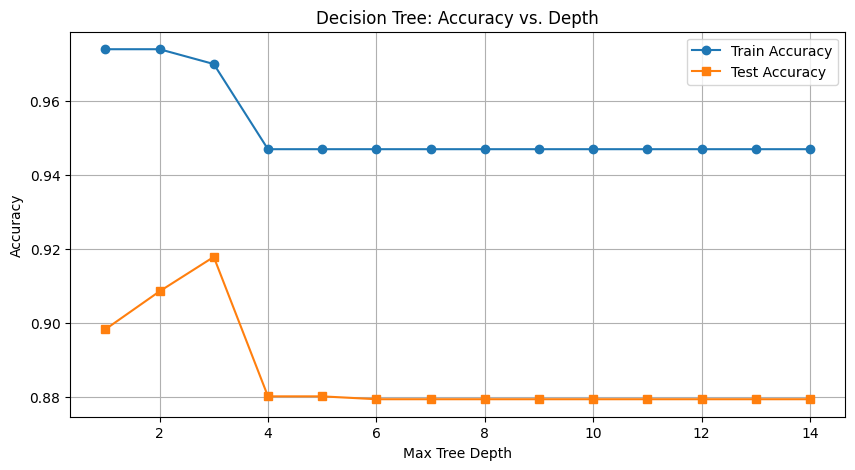

In [11]:
depths = range(1, 15)
train_accuracies = []
test_accuracies = []

for d in depths:
    # 1. Fit model with specific depth
    model = DecisionTree(data=train,
                     gain_function=entropy,
                     max_depth=d, 
                     min_samples=2,
                     max_features=40)
    model.fit(train)
    model._prune_recurs(model.root, val)
    # 2. Record performance
    train_accuracies.append(model.accuracy(train))
    test_accuracies.append(model.accuracy(test))

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs. Depth')
plt.legend()
plt.grid(True)
plt.show()

### Model Evaluation

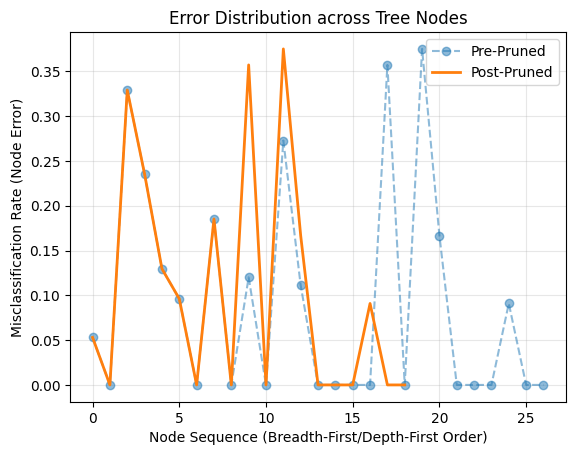

In [12]:
model = DecisionTree(data=train,
                    gain_function=entropy,
                    max_depth=10, 
                    min_samples=2,
                    max_features=10)
model.fit(train)

losses_pre = model._loss_plot_vec(train) 
model._prune_recurs(model.root, val)

losses_post = model._loss_plot_vec(train)

plt.plot(losses_pre, marker='o', linestyle='--', label='Pre-Pruned', alpha=0.5)
plt.plot(losses_post, label='Post-Pruned', linewidth=2)

plt.xlabel('Node Sequence (Breadth-First/Depth-First Order)')
plt.ylabel('Misclassification Rate (Node Error)')
plt.title('Error Distribution across Tree Nodes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [13]:
model = DecisionTree(data=train, max_depth=10, min_samples=2, max_features=10)
model.fit(train)

print("=== PRE-PRUNED TREE ===")
model.print_tree()
model._prune_recurs(model.root, val)

print("\n" + "="*25)
print("=== POST-PRUNED TREE ===")
model.print_tree()

=== PRE-PRUNED TREE ===
[Feature 9 < 0.8530]
  L:    Leaf: Prediction = 0
  R:    [Feature 4 < 146.2500]
      L:        [Feature 7 < 0.0065]
          L:            [Feature 5 < 69.0000]
              L:                [Feature 1 < 2.5000]
                  L:                    Leaf: Prediction = 1
                  R:                    [Feature 2 < 58.5000]
                      L:                        Leaf: Prediction = 0
                      R:                        [Feature 13 < 0.5000]
                          L:                            Leaf: Prediction = 1
                          R:                            [Feature 6 < 2236.9057]
                              L:                                [Feature 44 < 0.5000]
                                  L:                                    Leaf: Prediction = 1
                                  R:                                    Leaf: Prediction = 0
                              R:                                Leaf